In [1]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [2]:
import numpy as np

In [3]:
train_dir  = "60_ANH"

In [4]:
img_width, img_height = 200,200

In [5]:
train_datagen=ImageDataGenerator(
    rescale=1.0/225,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

In [6]:
train_generator=train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width,img_height),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 1544 images belonging to 31 classes.


In [7]:
model2 = Sequential([
    Conv2D(32,(3,3), activation='relu', input_shape=(200,200,3)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128,(3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(31, activation= 'softmax')
])

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model2.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])
model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 73728)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     9,437,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 31)             │         3,999 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,534,559 (36.37 MB)

 Trainable params: 9,534,559 (36.37 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
epochs=200
history=model2.fit(train_generator,epochs=epochs)

Epoch 1/200
49/49 ━━━━━━━━━━━━━━━━━━━━ 47s 936ms/step - accuracy: 0.0415 - loss: 3.4847
Epoch 2/200
49/49 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.0538 - loss: 3.3737
Epoch 3/200
49/49 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.0991 - loss: 3.2405
Epoch 4/200
49/49 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.1289 - loss: 3.0979
Epoch 5/200
49/49 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.1658 - loss: 2.9821
Epoch 6/200
49/49 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.1898 - loss: 2.8478
Epoch 7/200
49/49 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.2170 - loss: 2.7560
Epoch 8/200
49/49 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.2604 - loss: 2.6352
Epoch 9/200
49/49 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.2785 - loss: 2.5683
Epoch 10/200
49/49 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.2804 - loss: 2.5046
Epoch 11/200
49/49 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.3154 - loss: 2.4019
Epoch 12/200
49/49 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accura

In [10]:
import cv2

In [11]:
model2.save("facedetect.h5")

In [14]:
from keras.models import load_model
model1 = load_model("/Users/nguyenngockimtuyet/AI_HW/Model/facedetect.h5")

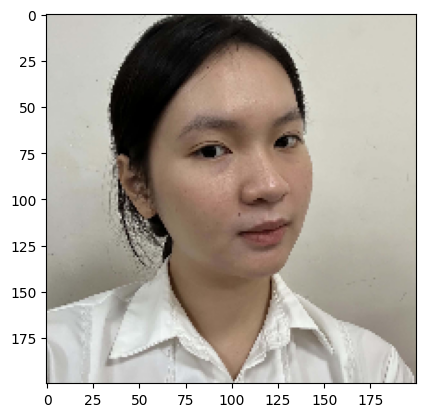

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Người tiên đoán: NGUYEN NGOC KIM TUYET
Độ tự tin: 99.03%


In [15]:
img = cv2.imread("/Users/nguyenngockimtuyet/AI_HW/520f20ad-3dc8-428f-afa2-c3d8659d1adf.jpeg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (200, 200))
plt.imshow(img_resized)
plt.show()
img_array = img_resized / 255.0
img_array = img_array.reshape(1, 200, 200, 3)
pred = model1.predict(img_array)
prediction = np.argmax(pred)
confidence = np.max(pred)
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Người tiên đoán: {person_name}")
print(f"Độ tự tin: {confidence * 100:.2f}%")

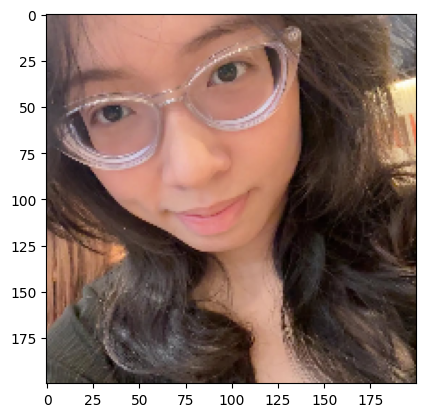

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Người tiên đoán: PHAM MAI PHUONG
Độ tự tin: 83.49%


In [17]:
img = cv2.imread("/Users/nguyenngockimtuyet/AI_HW/Test/a52d3599-02ca-41ac-bb12-fd323ce5aff7.jpeg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (200, 200))
plt.imshow(img_resized)
plt.show()
img_array = img_resized / 255.0
img_array = img_array.reshape(1, 200, 200, 3)
pred = model1.predict(img_array)
prediction = np.argmax(pred)
confidence = np.max(pred)
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Người tiên đoán: {person_name}")
print(f"Độ tự tin: {confidence * 100:.2f}%")

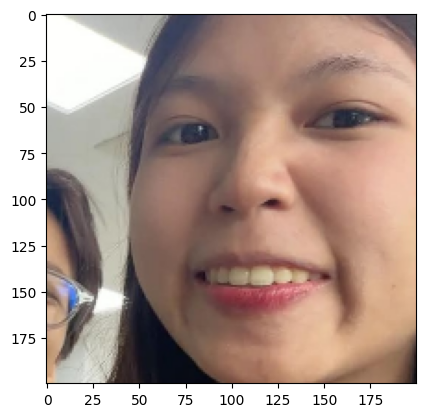

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Người tiên đoán: NGUYEN BAO HAN
Độ tự tin: 94.98%


In [18]:
img = cv2.imread("/Users/nguyenngockimtuyet/AI_HW/Test/cbdaca74-4d2b-4609-b372-6b29cddfc668.jpeg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (200, 200))
plt.imshow(img_resized)
plt.show()
img_array = img_resized / 255.0
img_array = img_array.reshape(1, 200, 200, 3)
pred = model1.predict(img_array)
prediction = np.argmax(pred)
confidence = np.max(pred)
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Người tiên đoán: {person_name}")
print(f"Độ tự tin: {confidence * 100:.2f}%")